# Anjana

This notebook walks through the deckard Python API from an ANJANA privacy-first perspective, while still covering the core modeling, attack, experiment, and plotting workflows.

## Navigation

1. Environment and imports
2. ANJANA dataset API
3. ANJANA defense and scorer overview
4. Core model API on anonymized data
5. Privacy attacks: membership inference + database reconstruction
6. End-to-end experiment composition
7. Yellowbrick plotter
8. Seaborn plotter

Each runnable section is introduced by markdown so the notebook can be read as a guided tour.

## 1. Environment and Imports

This setup cell imports the ANJANA extension and supporting deckard APIs, then prepares local artifact and plot directories.

### Environment requirements

Install the required extras before running this notebook:

```bash
pip install -e .[anjana,seaborn,yellowbrick]
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from deckard.attack import AttackConfig
from deckard.experiment import ExperimentConfig
from deckard.file import FileConfig
from deckard.model import ModelConfig
from deckard.plugins.anjana.data import AnjanaDataConfig
from deckard.plugins.anjana.score import DefaultAnjanaDataScorerConfig
from deckard.plugins.seaborn.plot import SeabornPlotConfig, SeabornPlotConfigList
from deckard.plugins.yellowbrick.plot import YellowbrickPlotConfig

NOTEBOOK_ROOT = Path(".")
ARTIFACT_DIR = NOTEBOOK_ROOT / "build" / "anjana"
PLOT_DIR = ARTIFACT_DIR / "plots"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Unique output file paths for each step
baseline_data_file = str(ARTIFACT_DIR / "anjana_baseline_data.pkl")
defended_data_file = str(ARTIFACT_DIR / "anjana_defended_data.pkl")
baseline_model_file = str(ARTIFACT_DIR / "anjana_baseline_sklearn_model.pkl")
defended_model_file = str(ARTIFACT_DIR / "anjana_defended_sklearn_model.pkl")
baseline_score_file = str(ARTIFACT_DIR / "anjana_baseline_scores.csv")
defended_score_file = str(ARTIFACT_DIR / "anjana_defended_scores.csv")
attack_baseline_file = str(ARTIFACT_DIR / "anjana_attack_baseline.pkl")
attack_defended_file = str(ARTIFACT_DIR / "anjana_attack_defended.pkl")
plot_file = str(ARTIFACT_DIR / "anjana_attack_plot.png")

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (8, 5)

print(f"Notebook root: {NOTEBOOK_ROOT}")
print(f"Artifacts directory: {ARTIFACT_DIR}")

/opt/hostedtoolcache/Python/3.10.20/x64/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Notebook root: .
Artifacts directory: build/anjana


## 2. ANJANA Dataset API (Baseline vs Defended)

This section builds two dataset configs on Adult:
- baseline dataset (no ANJANA defense)
- defended dataset (stronger k-anonymity defense, `k=10`)

Both are materialized so later sections can compare utility and privacy risk side-by-side.

In [2]:
baseline_anjana_data = AnjanaDataConfig(
    dataset_name="adult",
    data_params={},
    train_size=100,
    test_size=100,
    val_size=100,
    random_state=42,
    classifier=True,
    target="target",
    quasi_identifiers=["age", "education-num", "hours-per-week"],
    sensitive_attribute="sex",
    sensitive_columns=["sex"],
    anjana_defense=None,
    hierarchy_interval_sizes={
        "age": [5, 10, 20],
        "education-num": [2, 4],
        "hours-per-week": [5, 10, 20],
    },
    scorer=DefaultAnjanaDataScorerConfig(),
)

anjana_data = AnjanaDataConfig(
    dataset_name="adult",
    data_params={},
    train_size=0.75,
    test_size=0.25,
    random_state=42,
    classifier=True,
    target="target",
    quasi_identifiers=["age", "education-num", "hours-per-week"],
    sensitive_attribute="sex",
    sensitive_columns=["sex"],
    anjana_defense={
        "name": "anjana.anonymity.k_anonymity",
        "k": 10,
        "supp_level": 100,
    },
    hierarchy_interval_sizes={
        "age": [10, 20, 40],
        "education-num": [4, 8],
        "hours-per-week": [10, 20, 40],
    },
    scorer=DefaultAnjanaDataScorerConfig(),
)

baseline_anjana_scores = baseline_anjana_data(data_file=baseline_data_file)
anjana_scores = anjana_data(data_file=defended_data_file)

print("Baseline train/test:", baseline_anjana_data.train_n, baseline_anjana_data.test_n)
print("Defended train/test:", anjana_data.train_n, anjana_data.test_n)
print("Defended score keys (sample):", sorted(anjana_scores.keys())[:12])

pd.DataFrame(anjana_data.X_train).head()

Baseline train/test: 48642 100
Defended train/test: 23072 7691
Defended score keys (sample): ['class_count_max', 'class_count_min', 'class_imbalance_ratio', 'data_load_time', 'data_sample_time', 'k_anonymity', 'l_diversity', 'mutual_information_max', 'mutual_information_mean', 'num_classes', 'pipeline_fit_n', 'pipeline_fit_time']


,index,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,workclass_nan,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,...,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Outlying-US(Guam-USVI-etc),native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,native-country_nan,sex
0,44441,31,199368,13,0,0,50,1,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,37596,27,253814,13,0,0,40,0,0,1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
2,9274,57,182836,10,3103,0,40,0,0,0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
3,526,36,37778,13,0,0,40,0,0,1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,916,42,99203,9,3325,0,40,0,0,1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


## 3. ANJANA Defense and Scorer Overview

ANJANA in deckard exposes two defense hooks and a dedicated privacy scorer family.

### ANJANA defense types

- `anjana_defense`: applies a privacy transformation function (for example `k_anonymity`) directly to the tabular frame before splitting/scoring. This is where anonymization or suppression happens.
- `fairness_defense`: optional fairness-oriented preprocessing step injected into the pipeline (for example correlation-removal style preprocessing) to reduce sensitive-feature leakage and unfair dependence.
- `hierarchies` / `hierarchy_interval_sizes`: optional generalization controls used by anonymization defenses to map raw quasi-identifier values into broader buckets.

### ANJANA scorer types

`DefaultAnjanaDataScorerConfig` wraps three privacy metrics from the ANJANA/pycanon stack:

- `k_anonymity`: minimum equivalence-class size induced by quasi-identifiers.
- `l_diversity`: diversity of sensitive values inside each quasi-identifier group.
- `t_closeness`: distance between each group's sensitive-value distribution and the global distribution.

The cell below compares baseline vs defended data scores and renders a bar plot.

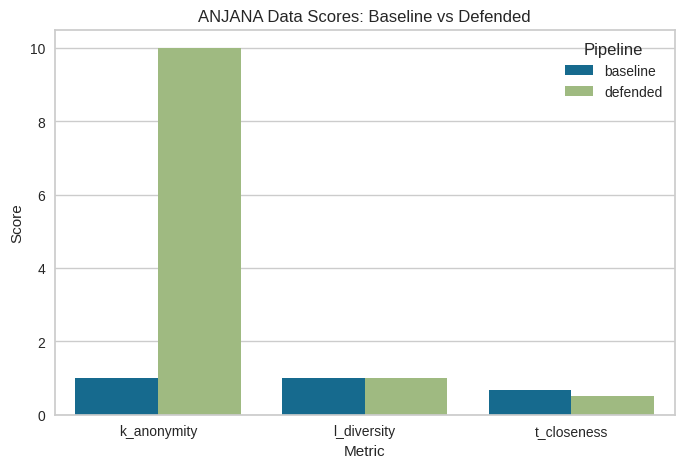

Data-score bar plot written: build/anjana/plots/anjana_data_scores_bar.png


,metric,pipeline,value
0,k_anonymity,baseline,1.000000
1,l_diversity,baseline,1.000000
2,t_closeness,baseline,0.668482
3,k_anonymity,defended,10.000000
4,l_diversity,defended,1.000000
5,t_closeness,defended,0.509860


In [3]:
all_score_keys = sorted(
    set(baseline_anjana_scores.keys()).union(set(anjana_scores.keys()))
)

# Keep only ANJANA privacy metrics for clean before/after comparison.
privacy_like_keys = [
    key
    for key in all_score_keys
    if key in {"k_anonymity", "l_diversity", "t_closeness"}
]



privacy_df = pd.DataFrame([
    {
        "metric": metric,
        "pipeline": "baseline",
        "value": baseline_anjana_scores.get(metric),
    }
    for metric in privacy_like_keys
] + [
    {
        "metric": metric,
        "pipeline": "defended",
        "value": anjana_scores.get(metric),
    }
    for metric in privacy_like_keys
])

privacy_csv = ARTIFACT_DIR / "anjana_data_scores_compare.csv"
privacy_df.to_csv(privacy_csv, index=False)

data_score_bar_path = (PLOT_DIR / "anjana_data_scores_bar.png").as_posix()
data_score_bar = SeabornPlotConfig(
    plot_type="bar",
    data_file=privacy_csv.as_posix(),
    x="metric",
    y="value",
    hue="pipeline",
    title="ANJANA Data Scores: Baseline vs Defended",
    xlabel="Metric",
    ylabel="Score",
    legend_title="Pipeline",
    plot_file=data_score_bar_path
)
_ = data_score_bar()
plt.show()
print("Data-score bar plot written:", data_score_bar_path)
privacy_df

## 4. Core Model API on Anonymized Data

A standard deckard model config works on the transformed ANJANA output. This trains a logistic regression classifier and reports basic predictive metrics.

In [4]:
baseline_model = ModelConfig(
    model_type="sklearn.linear_model.LogisticRegression",
    classifier=True,
    model_params={"max_iter": 100},
)

model = ModelConfig(
    model_type="sklearn.linear_model.LogisticRegression",
    classifier=True,
    model_params={"max_iter": 100},
)

baseline_model_scores = baseline_model(baseline_anjana_data, model_file=baseline_model_file)
model_scores = model(anjana_data, model_file=defended_model_file)

# Save scores to CSV
pd.DataFrame([baseline_model_scores]).to_csv(baseline_score_file, index=False)
pd.DataFrame([model_scores]).to_csv(defended_score_file, index=False)

print("Baseline accuracy:", baseline_model_scores.get("accuracy"))
print("Defended accuracy:", model_scores.get("accuracy"))
print("Defended prediction shape:", np.asarray(model.predictions).shape)

Baseline accuracy: 0.77
Defended accuracy: 0.8022
Defended prediction shape: (7691,)


## 5. Privacy Attacks: Membership Inference and Database Reconstruction

Instead of evasion, this section uses two privacy-focused inference attacks:

- Membership inference: predicts whether a record was part of model training.
- Database reconstruction: attempts to recover a missing row from known rows.

These better highlight confidentiality risk in privacy-sensitive workflows.

In [5]:
baseline_membership_attack = AttackConfig(
    attack_type="art.attacks.inference.membership_inference.MembershipInferenceBlackBox",
    attack_params={"input_type": "prediction"},
    attack_size=2,
    alias="membership_baseline_anjana",
)

membership_attack = AttackConfig(
    attack_type="art.attacks.inference.membership_inference.MembershipInferenceBlackBox",
    attack_params={"input_type": "prediction"},
    attack_size=2,
    alias="membership_defended_anjana",
)

baseline_membership_scores = baseline_membership_attack(
    data=baseline_anjana_data,
    model=baseline_model,
    attack_file=attack_baseline_file,
    score_file=baseline_score_file,
    )
membership_scores = membership_attack(
    data=anjana_data,
    model=model,
    attack_file=attack_defended_file,
    score_file=defended_score_file,
    )

membership_keys = [k for k in sorted(membership_scores.keys()) if k.startswith("membership_")]

print("Membership keys:", membership_keys)
print("Baseline membership accuracy:", baseline_membership_scores.get("membership_inference_accuracy"))
print("Defended membership accuracy:", membership_scores.get("membership_inference_accuracy"))
print("Baseline membership precision:", baseline_membership_scores.get("membership_inference_precision"))
print("Defended membership precision:", membership_scores.get("membership_inference_precision"))

Membership keys: ['membership_inference_accuracy', 'membership_inference_f1', 'membership_inference_precision', 'membership_inference_recall']
Baseline membership accuracy: 0.0
Defended membership accuracy: 0.5
Baseline membership precision: 0.0
Defended membership precision: 0.2


In [6]:
# Reconstruction attacks are slow. Uncomment at your own risk.
# reconstruction_attack = AttackConfig(
#     attack_type="art.attacks.inference.reconstruction.DatabaseReconstruction",
#     attack_params={"split": "train", "missing_index": -1},
#     attack_size=1,
#     alias="database_reconstruction_anjana",
# )

# reconstruction_scores = reconstruction_attack(data=anjana_data, model=model)
# reconstruction_keys = [k for k in sorted(reconstruction_scores.keys()) if k.startswith("database_reconstruction_")]

# print("Database reconstruction keys:", reconstruction_keys)
# print("Feature MSE:", reconstruction_scores.get("database_reconstruction_feature_mse"))
# print("Feature MAE:", reconstruction_scores.get("database_reconstruction_feature_mae"))
# print("Missing index:", reconstruction_scores.get("database_reconstruction_missing_index"))

## 6. End-to-End Experiment Composition

ExperimentConfig composes anonymized data, model, and a privacy-focused attack into one reproducible run. Here we use membership inference for the experiment-level attack profile.

In [7]:
baseline_experiment_files = FileConfig(
    data_file=(ARTIFACT_DIR / "baseline_experiment_data.pkl").as_posix(),
    model_file=(ARTIFACT_DIR / "baseline_experiment_model.pkl").as_posix(),
    score_file=(ARTIFACT_DIR / "baseline_experiment_scores.json").as_posix(),
)

defended_experiment_files = FileConfig(
    data_file=(ARTIFACT_DIR / "defended_experiment_data.pkl").as_posix(),
    model_file=(ARTIFACT_DIR / "defended_experiment_model.pkl").as_posix(),
    score_file=(ARTIFACT_DIR / "defended_experiment_scores.json").as_posix(),
)

baseline_experiment = ExperimentConfig(
    data=baseline_anjana_data,
    model=baseline_model,
    attack=baseline_membership_attack,
    files=baseline_experiment_files
)
baseline_experiment_scores = baseline_experiment()

experiment = ExperimentConfig(
    data=anjana_data,
    model=model,
    attack=membership_attack,
    files=defended_experiment_files
)
experiment_scores = experiment()

## 7. Yellowbrick Plotter

Yellowbrick plots can be generated from an experiment built on ANJANA-prepared data. This example renders an ROC AUC plot.

Yellowbrick plot written: build/anjana/plots/anjana_yellowbrick_roc_auc.png


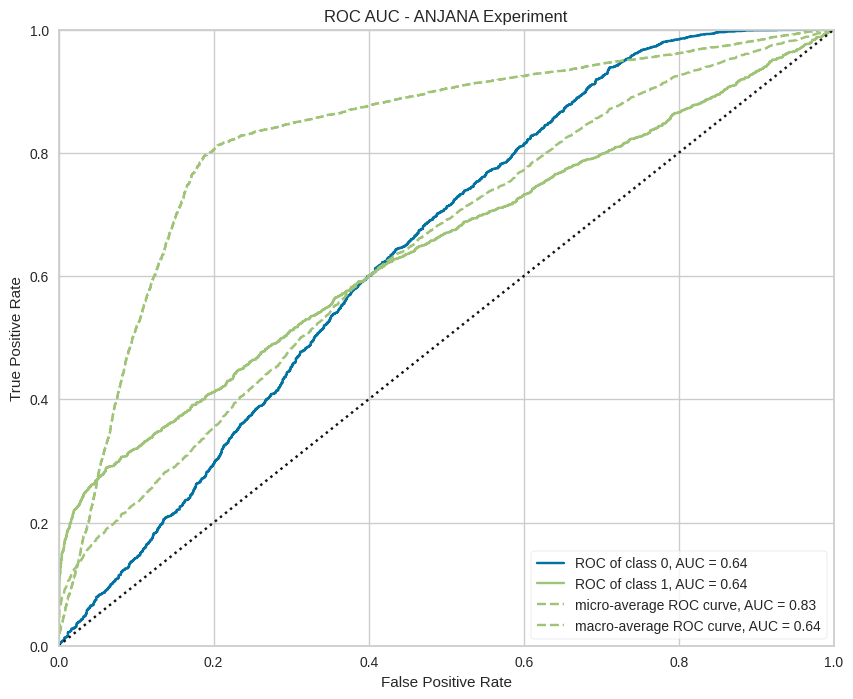

In [8]:
yellowbrick_path = (PLOT_DIR / "anjana_yellowbrick_roc_auc.png").as_posix()

yellowbrick_plot = YellowbrickPlotConfig(
    experiment=experiment,
    plot_type="roc_auc",
    features="all",
    classes="all",
    title="ROC AUC - ANJANA Experiment",
    save_path=yellowbrick_path
)

yellowbrick_plot()
print("Yellowbrick plot written:", yellowbrick_path)

## 8. Seaborn Plotter

This section compares baseline vs defended pipelines side-by-side using a Seaborn plot list:
- left: membership-attack metrics bar plot
- right: ANJANA data-score bar plot

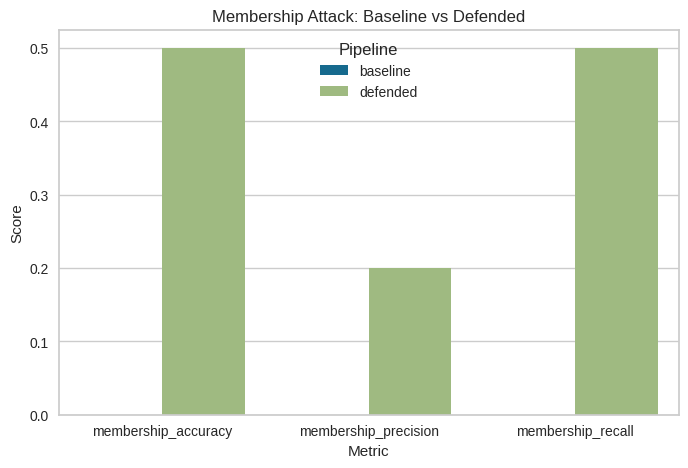

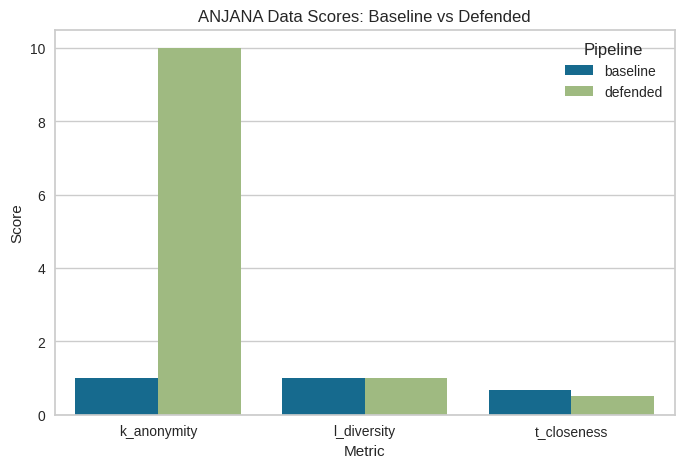

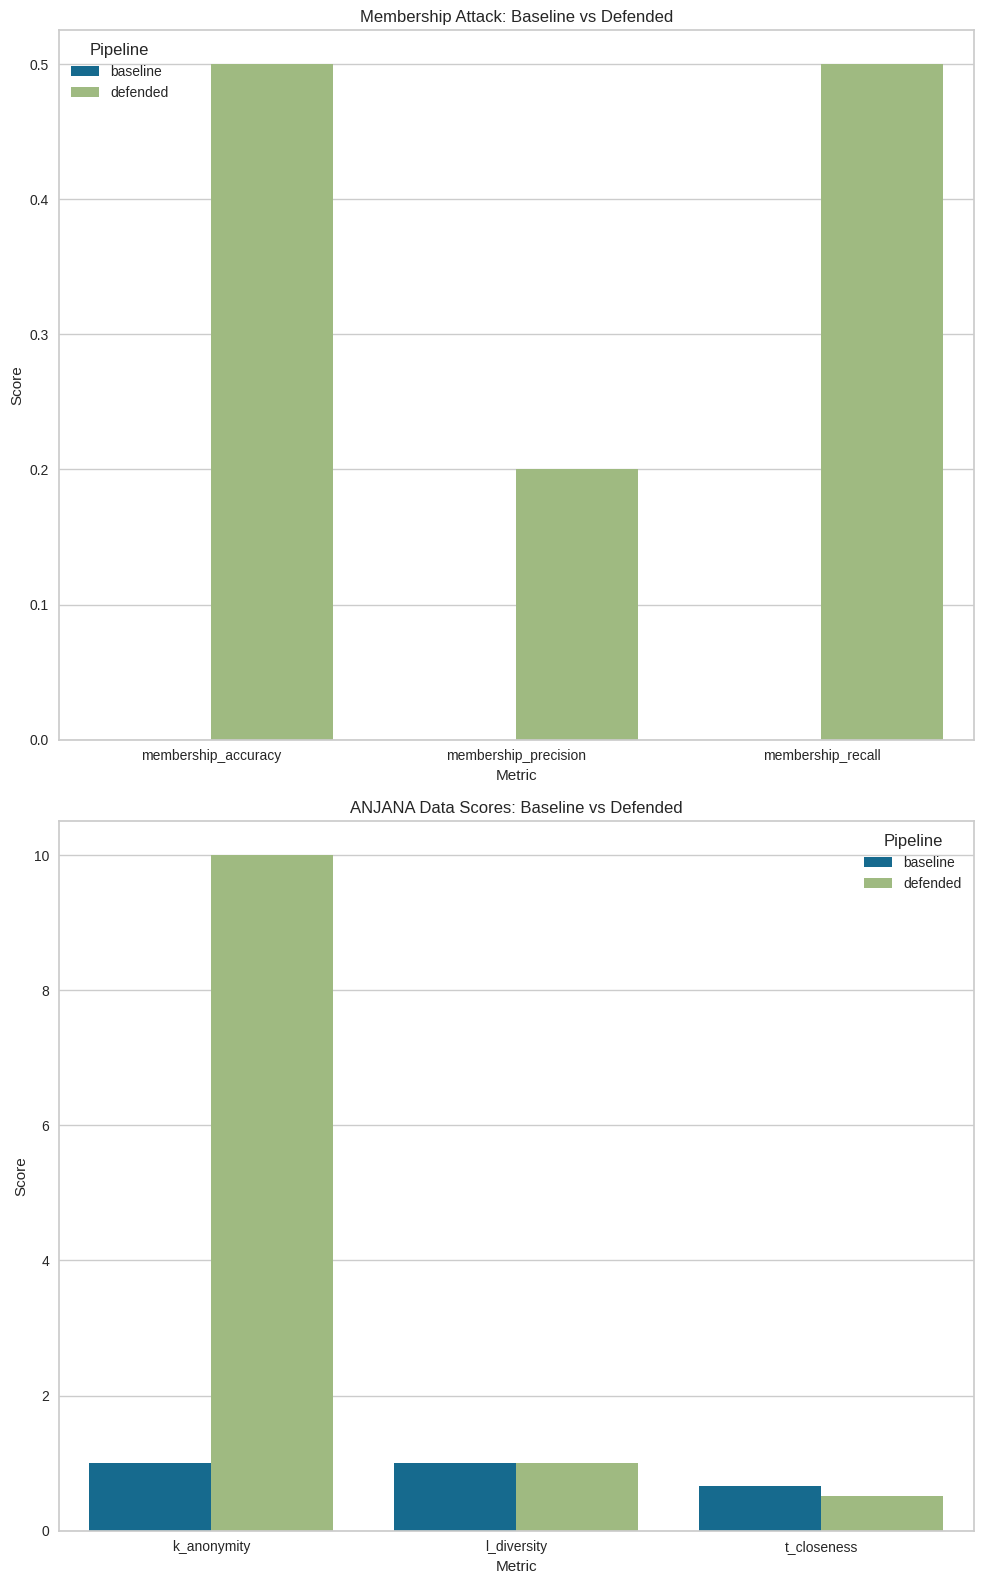

Seaborn comparison plots written: build/anjana/plots/anjana_attack_compare_bar.png build/anjana/plots/anjana_data_compare_bar_side_by_side.png


,metric,value,pipeline,panel
0,membership_accuracy,0.0,baseline,attack
1,membership_precision,0.0,baseline,attack
2,membership_recall,0.0,baseline,attack
3,membership_accuracy,0.5,defended,attack
4,membership_precision,0.2,defended,attack
5,membership_recall,0.5,defended,attack


In [9]:
attack_compare = pd.DataFrame([
    {
        "metric": "membership_accuracy",
        "value": float(baseline_membership_scores.get("membership_inference_accuracy", np.nan)),
        "pipeline": "baseline",
        "panel": "attack",
    },
    {
        "metric": "membership_precision",
        "value": float(baseline_membership_scores.get("membership_inference_precision", np.nan)),
        "pipeline": "baseline",
        "panel": "attack",
    },
    {
        "metric": "membership_recall",
        "value": float(baseline_membership_scores.get("membership_inference_recall", np.nan)),
        "pipeline": "baseline",
        "panel": "attack",
    },
    {
        "metric": "membership_accuracy",
        "value": float(membership_scores.get("membership_inference_accuracy", np.nan)),
        "pipeline": "defended",
        "panel": "attack",
    },
    {
        "metric": "membership_precision",
        "value": float(membership_scores.get("membership_inference_precision", np.nan)),
        "pipeline": "defended",
        "panel": "attack",
    },
    {
        "metric": "membership_recall",
        "value": float(membership_scores.get("membership_inference_recall", np.nan)),
        "pipeline": "defended",
        "panel": "attack",
    },
])

anjana_data_compare = privacy_df.copy()

attack_csv = ARTIFACT_DIR / "anjana_attack_compare.csv"
data_csv = ARTIFACT_DIR / "anjana_data_score_compare.csv"
attack_compare.to_csv(attack_csv, index=False)
anjana_data_compare.to_csv(data_csv, index=False)

attack_bar_path = (PLOT_DIR / "anjana_attack_compare_bar.png").as_posix()
data_bar_path = (PLOT_DIR / "anjana_data_compare_bar_side_by_side.png").as_posix()

attack_bar = SeabornPlotConfig(
    plot_type="bar",
    data_file=attack_csv.as_posix(),
    x="metric",
    y="value",
    hue="pipeline",
    title="Membership Attack: Baseline vs Defended",
    xlabel="Metric",
    ylabel="Score",
    legend_title="Pipeline",
    plot_file=attack_bar_path,
)
_ = attack_bar()

data_bar = SeabornPlotConfig(
    plot_type="bar",
    data_file=data_csv.as_posix(),
    x="metric",
    y="value",
    hue="pipeline",
    title="ANJANA Data Scores: Baseline vs Defended",
    xlabel="Metric",
    ylabel="Score",
    legend_title="Pipeline",
    plot_file=data_bar_path,
)
_ = data_bar()

plot_list = SeabornPlotConfigList(
    data_file=attack_csv.as_posix(),
    plots=[attack_bar, data_bar],
)

_ = plot_list()
plt.show()

print("Seaborn comparison plots written:", attack_bar_path, data_bar_path)
attack_compare

In [10]:
# Diagnostic: verify whether ANJANA defense changed the underlying dataset.
baseline_X = baseline_anjana_data._X.copy()
defended_X = anjana_data._X.copy()

print("Baseline rows/cols:", baseline_X.shape)
print("Defended rows/cols:", defended_X.shape)
print("Same columns:", list(baseline_X.columns) == list(defended_X.columns))

shared_idx = baseline_X.index.intersection(defended_X.index)
if len(shared_idx) > 0 and list(baseline_X.columns) == list(defended_X.columns):
    changed_cells = (baseline_X.loc[shared_idx] != defended_X.loc[shared_idx]).sum().sum()
    print("Changed cells on shared index:", int(changed_cells))
else:
    print("No direct shared-index cell comparison available")

print("Privacy scores baseline:", {k: baseline_anjana_scores.get(k) for k in ["k_anonymity", "l_diversity", "t_closeness"]})
print("Privacy scores defended:", {k: anjana_scores.get(k) for k in ["k_anonymity", "l_diversity", "t_closeness"]})

# Quick sweep: look for stronger defense settings that move privacy metrics more clearly.
for candidate_k in [2, 5, 10, 20]:
    probe = AnjanaDataConfig(
        dataset_name="adult",
        data_params={},
        train_size=0.75,
        test_size=0.25,
        random_state=42,
        classifier=True,
        target="target",
        quasi_identifiers=["age", "education-num", "hours-per-week"],
        sensitive_attribute="sex",
        sensitive_columns=["sex"],
        anjana_defense={
            "name": "anjana.anonymity.k_anonymity",
            "k": candidate_k,
            "supp_level": 100,
        },
        hierarchy_interval_sizes={
            "age": [10, 20, 40],
            "education-num": [4, 8],
            "hours-per-week": [10, 20, 40],
        },
        scorer=DefaultAnjanaDataScorerConfig(),
    )
    probe_scores = probe()
    print(
        f"k={candidate_k}: rows={probe._X.shape[0]}, "
        f"k_anonymity={probe_scores.get('k_anonymity')}, "
        f"l_diversity={probe_scores.get('l_diversity')}, "
        f"t_closeness={probe_scores.get('t_closeness')}"
    )

Baseline rows/cols: (48842, 104)
Defended rows/cols: (30763, 105)
Same columns: False
No direct shared-index cell comparison available
Privacy scores baseline: {'k_anonymity': 1.0, 'l_diversity': 1.0, 't_closeness': 0.6684820441423365}
Privacy scores defended: {'k_anonymity': 10.0, 'l_diversity': 1.0, 't_closeness': 0.5098603300501685}


k=2: rows=43325, k_anonymity=2.0, l_diversity=1.0, t_closeness=0.6722908251586843


k=5: rows=36400, k_anonymity=5.0, l_diversity=1.0, t_closeness=0.6768681318681319


k=10: rows=30763, k_anonymity=10.0, l_diversity=1.0, t_closeness=0.5098603300501685


k=20: rows=24502, k_anonymity=20.0, l_diversity=1.0, t_closeness=0.49027193115430817


## Optional Dependencies

This notebook covers Anjana privacy workflows with plotting outputs.

Recommended extras:

- `docs`
- `anjana`
- `seaborn`
- `yellowbrick`

Install from repository root:

```bash
pip install -e '.[docs,anjana,seaborn,yellowbrick]'
```

In [11]:
# Optional dependency installation (run only if your environment is missing packages)
# !pip install -e '../../.[docs,anjana,seaborn,yellowbrick]'